## Activity 7

In [40]:
# Module 2 Activity 7 & 8

# Activity 7 
# Part I: 
# By Jasmine

import numpy as np
import matplotlib.pyplot as plt

mu_real = 0
sigma_real_sq = 4
size = 100
mu_prior = 2
sigma_prior_sq = 10

data = np.random.normal(mu_real, np.sqrt(sigma_real_sq), size)

for N in range(1, size+1): 

    x_n = data[:N]
    
    mu_ML = np.mean(x_n)
    
    denominator = (N * np.sqrt(sigma_real_sq)) + np.sqrt(sigma_prior_sq)
    term1 = (np.sqrt(sigma_prior_sq) / denominator) * mu_real
    term2 = (N * np.sqrt(sigma_real_sq) / denominator) * mu_ML
    mu_N = term1 + term2

print(f"{size:3d} | {mu_ML:10.4f} | {mu_N:20.5f}")

100 |     0.0557 |              0.05484


#### Write-up: 
$\mu_{N}$ gets closer to $\mu_{ML}$ when $N$ gets larger. 

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
/tmp/xpython_42/1324096746.py:29: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Posterior of $\mu$ (Known $\sigma^2$)")
/tmp/xpython_42/1324096746.py:30: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$ values')


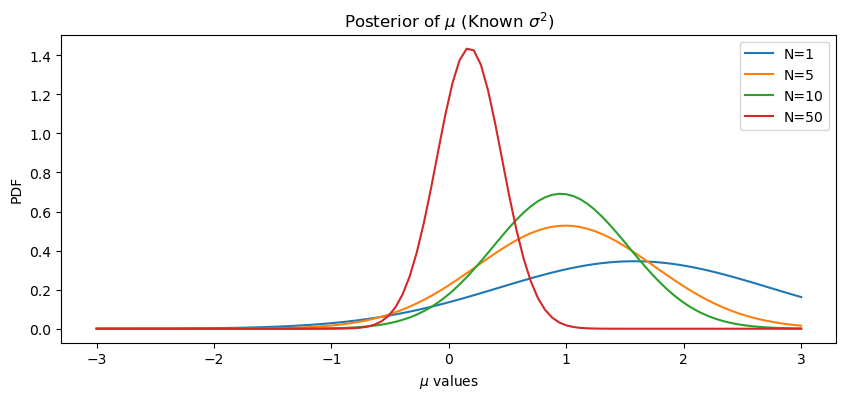

In [41]:
# Part I: infering mu

from scipy.stats import norm, gamma

# Priors
mu_0 = 2
sigma_0_sq = 2

def infer_mu(data_batch, mu_prior, var_prior, var_known):
    N = len(data_batch)
    mu_ML = np.mean(data_batch)
    
    prec_N = (1/var_prior) + (N/var_known)
    var_N = 1 / prec_N
    
    denom = (N * var_prior) + var_known
    mu_N = (var_known/denom)*mu_prior + (N*var_prior/denom)*mu_ML
    
    return mu_N, var_N

n_samples = [1, 5, 10, 50]
x_axis = np.linspace(-3, 3, 100)

plt.figure(figsize=(10, 4))
for n in n_samples:
    m_n, v_n = infer_mu(data[:n], mu_0, sigma_0_sq, sigma_real_sq)
    plt.plot(x_axis, norm.pdf(x_axis, m_n, np.sqrt(v_n)), label=f'N={n}')

plt.title("Posterior of $\mu$ (Known $\sigma^2$)")
plt.xlabel('$\mu$ values')
plt.ylabel('PDF')
plt.legend()
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/tmp/xpython_42/2445191524.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Posterior Distribution of Precision $\lambda$")
/tmp/xpython_42/2445191524.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


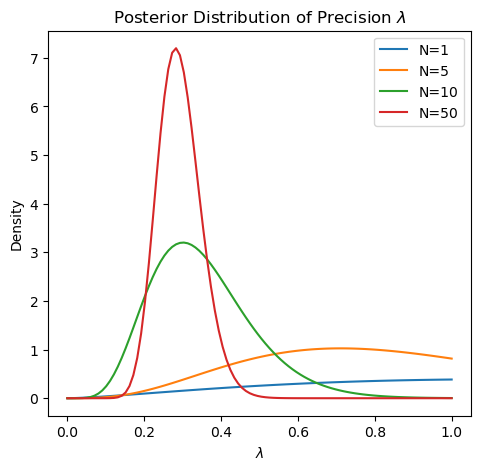

In [42]:
# Part II: Inferring sigma^2
# Prior parameters for precision (call it lambda) are (a_0, b_0)
a_0, b_0 = 2, 1 

# Sequential updating
n_values = [1, 5, 10, 50]
precisions = np.linspace(0, 1, 100)

# Plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for n in n_values:
    x_n = data[:n]
    a_n = a_0 + n/2
    b_n = b_0 + 0.5 * np.sum((x_n - mu_real)**2)
    
    posterior = gamma.pdf(precisions, a_n, scale=1/b_n)
    plt.plot(precisions, posterior, label=f'N={n}')

plt.title("Posterior Distribution of Precision $\lambda$")
plt.xlabel("$\lambda$")
plt.ylabel("Density")
plt.legend()
plt.show()

#### Write-up: 
The conjugate prior, according to the textbook, is our prior guess. To implement Baysian Inference, we can develope a for loop to keep updating the inferred term (in our case are $\mu$ or $\sigma^2$).

## Activity 8

In [43]:
# Activity 8 
# Part I: 

mu_real = 0
sigma_real_sq = 4
size = 100
mu_prior = 2
sigma_prior_sq = 100 # broader prior

data = np.random.normal(mu_real, np.sqrt(sigma_real_sq), size)

for N in range(1, size+1): 

    x_n = data[:N]
    
    mu_ML = np.mean(x_n)
    
    denominator = (N * np.sqrt(sigma_real_sq)) + np.sqrt(sigma_prior_sq)
    term1 = (np.sqrt(sigma_prior_sq) / denominator) * mu_real
    term2 = (N * np.sqrt(sigma_real_sq) / denominator) * mu_ML
    mu_N = term1 + term2

print(f"{size:3d} | {mu_ML:10.4f} | {mu_N:20.5f}")

100 |     0.3203 |              0.30509


<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
/tmp/xpython_42/3006748146.py:29: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Posterior of $\mu$ (Known $\sigma^2$)")
/tmp/xpython_42/3006748146.py:30: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$ values')


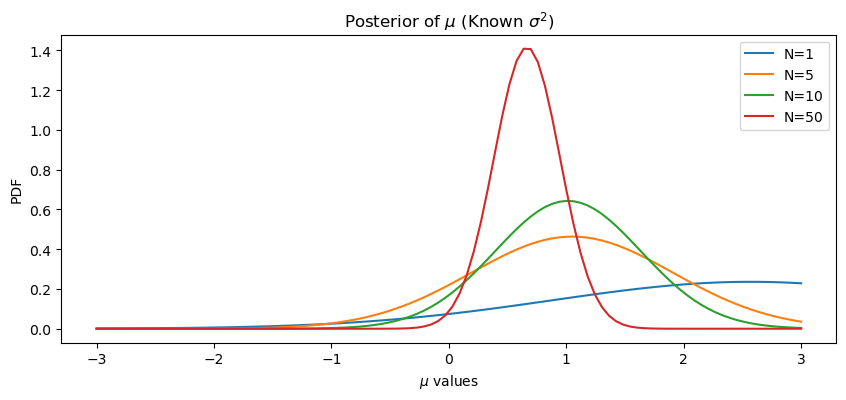

In [44]:
# Part I: infering mu with broader prior

from scipy.stats import norm, gamma

# Priors
mu_0 = 2
sigma_0_sq = 10

def infer_mu(data_batch, mu_prior, var_prior, var_known):
    N = len(data_batch)
    mu_ML = np.mean(data_batch)
    
    prec_N = (1/var_prior) + (N/var_known)
    var_N = 1 / prec_N
    
    denom = (N * var_prior) + var_known
    mu_N = (var_known/denom)*mu_prior + (N*var_prior/denom)*mu_ML
    
    return mu_N, var_N

n_samples = [1, 5, 10, 50]
x_axis = np.linspace(-3, 3, 100)

plt.figure(figsize=(10, 4))
for n in n_samples:
    m_n, v_n = infer_mu(data[:n], mu_0, sigma_0_sq, sigma_real_sq)
    plt.plot(x_axis, norm.pdf(x_axis, m_n, np.sqrt(v_n)), label=f'N={n}')

plt.title("Posterior of $\mu$ (Known $\sigma^2$)")
plt.xlabel('$\mu$ values')
plt.ylabel('PDF')
plt.legend()
plt.show()

#### Write-up: 
With a broader priors, the mean $\mu$s shift to the left (smaller mean), with bigger N still giving better estimation of the true mean. 

<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/tmp/xpython_42/1490015250.py:27: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Posterior of $\mu$ (Known $\sigma^2$)")
/tmp/xpython_42/1490015250.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$ values')


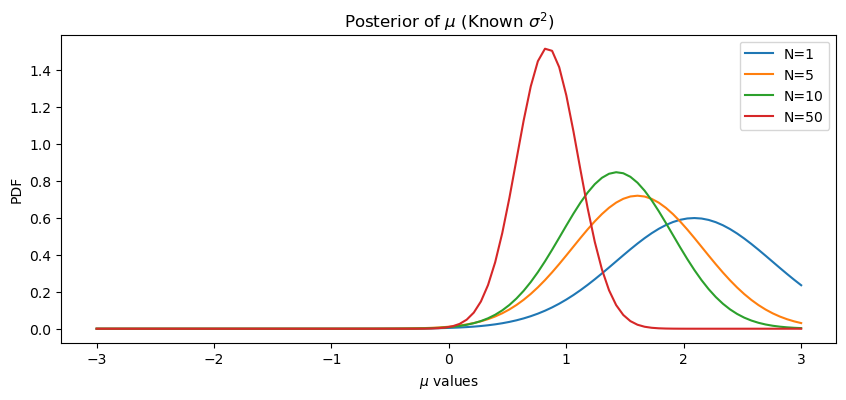

In [47]:
# Part I: infering mu with narrorer prior

# Priors
mu_0 = 2
sigma_0_sq = 0.5

def infer_mu(data_batch, mu_prior, var_prior, var_known):
    N = len(data_batch)
    mu_ML = np.mean(data_batch)
    
    prec_N = (1/var_prior) + (N/var_known)
    var_N = 1 / prec_N
    
    denom = (N * var_prior) + var_known
    mu_N = (var_known/denom)*mu_prior + (N*var_prior/denom)*mu_ML
    
    return mu_N, var_N

n_samples = [1, 5, 10, 50]
x_axis = np.linspace(-3, 3, 100)

plt.figure(figsize=(10, 4))
for n in n_samples:
    m_n, v_n = infer_mu(data[:n], mu_0, sigma_0_sq, sigma_real_sq)
    plt.plot(x_axis, norm.pdf(x_axis, m_n, np.sqrt(v_n)), label=f'N={n}')

plt.title("Posterior of $\mu$ (Known $\sigma^2$)")
plt.xlabel('$\mu$ values')
plt.ylabel('PDF')
plt.legend()
plt.show()

#### Write-up: 
With a narrorer priors, the mean $\mu$s shift to the right (larger mean), with bigger N still giving better estimation of the true mean. 

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\m'
/tmp/xpython_42/1376254997.py:37: SyntaxWarning: invalid escape sequence '\m'
  ax.axvline(mu_real, color='black', linestyle='--', alpha=0.5, label='True $\mu$')
/tmp/xpython_42/1376254997.py:38: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Posterior Evolution: {label}\n($\sigma_0^2 = {sig_0_sq}$)")
/tmp/xpython_42/1376254997.py:39: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$\mu$")


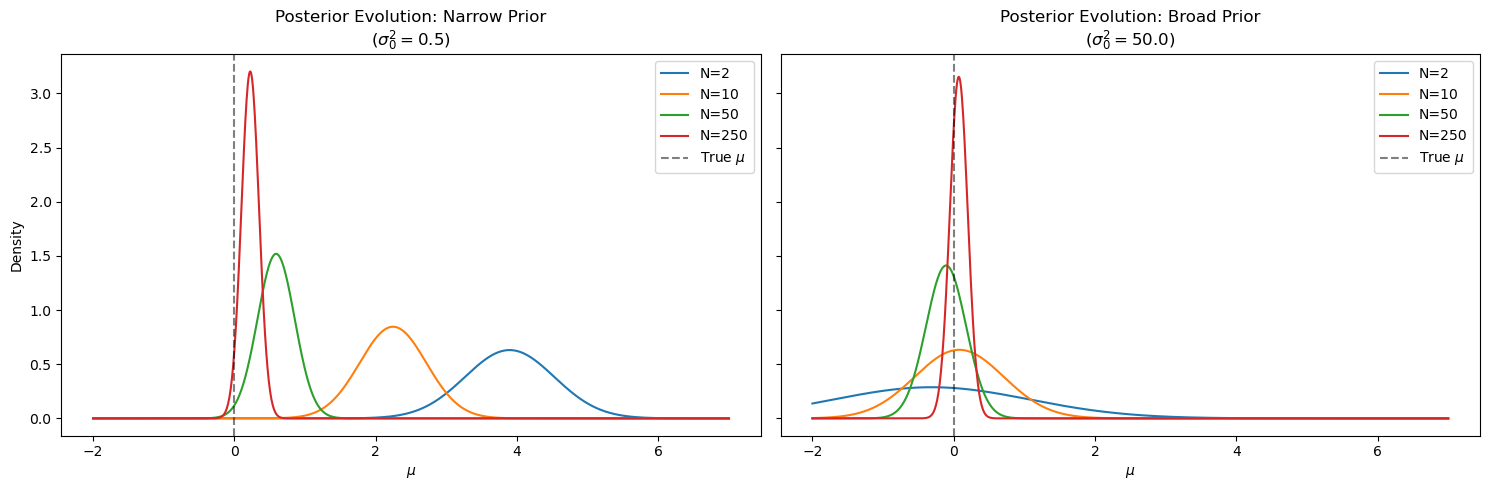

In [50]:
# Re-define everything here; 
mu_real = 0
sigma_sq = 4  
N_max = 500
data = np.random.normal(mu_real, np.sqrt(sigma_sq), N_max)

def infer_mu(data_batch, mu_prior, var_prior, var_known):
    N = len(data_batch)
    mu_ML = np.mean(data_batch) if N > 0 else 0
    
    prec_N = (1/var_prior) + (N/var_known)
    var_N = 1 / prec_N
    
    denom = (N * var_prior) + var_known
    mu_N = (var_known/denom)*mu_prior + (N*var_prior/denom)*mu_ML
    
    return mu_N, var_N

# Re-define Priors
mu_0 = 5  
priors = {'Narrow Prior': 0.5,  
          'Broad Prior': 50.0}

# Experiment for different N
n_sizes = [2, 10, 50, 250]
x_axis = np.linspace(-2, 7, 1000)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for i, (label, sig_0_sq) in enumerate(priors.items()):
    ax = axes[i]
    for n in n_sizes:
        m_n, v_n = infer_mu(data[:n], mu_0, sig_0_sq, sigma_sq)
        ax.plot(x_axis, norm.pdf(x_axis, m_n, np.sqrt(v_n)), label=f'N={n}')
    
    # Plot the true mean for reference
    ax.axvline(mu_real, color='black', linestyle='--', alpha=0.5, label='True $\mu$')
    ax.set_title(f"Posterior Evolution: {label}\n($\sigma_0^2 = {sig_0_sq}$)")
    ax.set_xlabel("$\mu$")
    ax.legend()

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()

#### Write-up: 
1. With a bigger $\sigma^2$, regardless of data size the accuracy of estimating the true mean is pretty good.
2. For both $\sigma^2$s, as $N$ goes larger, the prior guessing affects the final mean estimation less, which I interpreted it as when you have a large data base, your guess becomes less important for the final est. of mean. 